# Point Source Injector

<div class="alert alert-block alert-info">

The source injector can produce mock simulated data independent of the MEGAlib software.

Standard data simulation requires the users to install and use MEGAlib to convolve the source model with the detector effects to generate data. The source injector utilizes the response generated by intensive simulation, which contains the statistical detector effects. With the source injector, you can convolve response, source model, and orientation to gain the mock data quickly.

The advantages of using the source injector include:

- No need to install and use MEGAlib
- Get the data much faster than the standard simulation pipeline
- The generated data are in the format that can be used for spectral fitting, localization, imaging, etc.

The disadvantages are:

- The data are binned based on the binning of the response, which means that you lost the unbinned event distribution as you will get from the MEGAlib pipeline.
- If the response is coarse, the data you generated might not be precise.


In [1]:
%%capture
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import curve_fit

import astropy.units as u
from astropy.coordinates import SkyCoord

from astromodels.core.polarization import LinearPolarization

from threeML import *

from histpy import Histogram
from mhealpy import HealpixMap

from cosipy import BinnedData, SpacecraftHistory, SourceInjector
from cosipy.event_selection import GoodTimeInterval
from cosipy.polarization.conventions import IAUPolarizationConvention
from cosipy.polarization.polarization_angle import PolarizationAngle
from cosipy.threeml.custom_functions import SpecFromDat
from cosipy.util import fetch_wasabi_file

%matplotlib inline


## Get the data

The data can be downloaded by running the cells below. Each respective cell also gives the wasabi file path and file size.


In [2]:
%%capture
response_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"

In [3]:
%%capture
orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"

## NGC 1068

### Thermal

In [33]:
source = "NGC1068"
model_tag = "cpl"
index_tag = -2.10
norm_nt = 0
K_inj = 3.1e-1 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 128. * u.keV
index_inj = index_tag

spectrum_inj_1068 = Cutoff_powerlaw()

spectrum_inj_1068.K.value = K_inj.value
spectrum_inj_1068.piv.value = piv_inj.value
spectrum_inj_1068.xc.value = xc_inj.value
spectrum_inj_1068.index.value = index_inj

spectrum_inj_1068.K.unit = K_inj.unit
spectrum_inj_1068.piv.unit = piv_inj.unit
spectrum_inj_1068.xc.unit = xc_inj.unit

l = 172.104  # Galactic longitude, degrees
b = -51.934  # Galactic latitude, degrees

### Non-thermal powerlaw

In [39]:
model_tag = "cpl_pl"
norm_nt = 0.42
index_tag = -2.8
K_inj = norm_nt*spectrum_inj_1068.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200. * u.keV
index_inj = index_tag

spectrum_inj_1068_PL = Powerlaw()

spectrum_inj_1068_PL.K.value = K_inj.value
spectrum_inj_1068_PL.piv.value = piv_inj.value
spectrum_inj_1068_PL.index.value = index_inj

spectrum_inj_1068_PL.K.unit = K_inj.unit
spectrum_inj_1068_PL.piv.unit = piv_inj.unit

# Non-thermal fraction of the 0.1-10 MeV (100-10000 keV) energy flux.
energy_flux_min_keV = 100.0
energy_flux_max_keV = 10000.0
thermal_energy_flux, _ = quad(
    lambda energy: energy * spectrum_inj_1068.evaluate_at(energy),
    energy_flux_min_keV,
    energy_flux_max_keV,
)
nonthermal_energy_flux, _ = quad(
    lambda energy: energy * spectrum_inj_1068_PL.evaluate_at(energy),
    energy_flux_min_keV,
    energy_flux_max_keV,
)
total_energy_flux = thermal_energy_flux + nonthermal_energy_flux
nonthermal_energy_flux_fraction = nonthermal_energy_flux / total_energy_flux
nonthermal_energy_flux_erg = nonthermal_energy_flux * u.keV.to(u.erg)

print(
    f"Non-thermal 0.1-10 MeV "
    f"energy-flux fraction: {nonthermal_energy_flux_fraction:.4f} "
    f"({100 * nonthermal_energy_flux_fraction:.2f}%)"
)
print(
    f"Non-thermal energy flux: {nonthermal_energy_flux_erg:.2e} "
    r"erg cm^-2 s^-1"
)
print(
    f"Norm: {K_inj:.2e} "
    r"keV^-1 cm^-2 s^-1"
)

Non-thermal 0.1-10 MeV energy-flux fraction: 0.3632 (36.32%)
Non-thermal energy flux: 5.46e-11 erg cm^-2 s^-1
Norm: 4.02e-07 1 / (keV s cm2) keV^-1 cm^-2 s^-1


In [ ]:
# model_tag = "cpl_bpl"
# spectrum_inj_1068_PL_unbroken = spectrum_inj_1068_PL

# break_energy = 200.0 * u.keV
# index_below_break = -2
# index_above_break = spectrum_inj_1068_PL_unbroken.index.value
# K_at_break = (
#     spectrum_inj_1068_PL_unbroken.evaluate_at(break_energy.value)
#     / u.cm / u.cm / u.s / u.keV
# )

# spectrum_inj_1068_BPL = Broken_powerlaw()
# spectrum_inj_1068_BPL.K.value = K_at_break.value
# spectrum_inj_1068_BPL.xb.value = break_energy.value
# spectrum_inj_1068_BPL.piv.value = break_energy.value
# spectrum_inj_1068_BPL.alpha.value = index_below_break
# spectrum_inj_1068_BPL.beta.value = index_above_break
# spectrum_inj_1068_BPL.K.unit = K_at_break.unit
# spectrum_inj_1068_BPL.xb.unit = break_energy.unit
# spectrum_inj_1068_BPL.piv.unit = break_energy.unit

# # Keep the existing variable name so the plotting cells below use the BPL.
# spectrum_inj_1068_PL = spectrum_inj_1068_BPL

# # Non-thermal fraction of the 0.1-10 MeV (100-10000 keV) energy flux.
# energy_flux_min_keV = 100.0
# energy_flux_max_keV = 10000.0
# thermal_energy_flux, _ = quad(
#     lambda energy: energy * spectrum_inj_1068.evaluate_at(energy),
#     energy_flux_min_keV,
#     energy_flux_max_keV,
# )
# nonthermal_energy_flux, _ = quad(
#     lambda energy: energy * spectrum_inj_1068_PL.evaluate_at(energy),
#     energy_flux_min_keV,
#     energy_flux_max_keV,
# )
# total_energy_flux = thermal_energy_flux + nonthermal_energy_flux
# nonthermal_energy_flux_fraction = nonthermal_energy_flux / total_energy_flux

# print(
#     f"Non-thermal 0.1-10 MeV "
#     f"energy-flux fraction: {nonthermal_energy_flux_fraction:.4f} "
#     f"({100 * nonthermal_energy_flux_fraction:.2f}%)"
# )

Non-thermal 0.1-10 MeV energy-flux fraction: 0.2481 (24.81%)


### Non-thermal Cutoff-powerlaw

In [40]:
# Define the coordinate of the point source
source_coord = SkyCoord(l=l, b=b, frame="galactic", unit="deg")

# # # cpl
# point_source = PointSource(
#     source, l=source_coord.l.deg, b=source_coord.b.deg, spectral_shape=spectrum_inj_1068
# )

# # pl
# model_tag = "pl"
# point_source = PointSource(
#     "NGC1068", l=source_coord.l.deg, b=source_coord.b.deg, spectral_shape=(spectrum_inj_1068_PL)
# )

# cpl + pl
point_source = PointSource(
    "NGC1068", l=source_coord.l.deg, b=source_coord.b.deg, spectral_shape=(spectrum_inj_1068 + spectrum_inj_1068_PL)
)

# define the model. The model can contain multiple point sources.
model = Model(point_source)

### Read orientation file


In [41]:
# Read the three-month orientation and retain only intervals where NGC 1068
# is within 60 degrees of the spacecraft boresight.
ori = SpacecraftHistory.open(orientation_path)
fov_cut = 60 * u.deg

source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    ori,
    fov_cut,
    earth_occ=False,
)
ori_fov60 = ori.apply_gti(source_gti)

print(f"FOV cut: {fov_cut.to_value(u.deg):.0f} deg")
print(f"GTI intervals: {len(source_gti):,}")
print(f"Selected livetime: {ori_fov60.cumulative_livetime().to_value(u.s):,.1f} s")

FOV cut: 60 deg
GTI intervals: 1,300
Selected livetime: 2,546,115.0 s


### Existing NGC 1068 background histogram


### Inject and save the manually configured model


In [42]:
# Define an injector by the response
injector = SourceInjector(response_path=response_path)

In [43]:
%%time

output_dir = Path("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models")
output_dir.mkdir(parents=True, exist_ok=True)

cutoff_keV = int(spectrum_inj_1068.xc.value)
norm_nt_suffix = ""
if (model_tag == "cpl_pl" or model_tag == "pl"):
    norm_nt_tag = np.format_float_positional(float(norm_nt), trim="-").replace(".", "p")
    norm_nt_suffix = f"_normNT_{norm_nt_tag}"

source_file = output_dir / (
    f"{source}_ec_{cutoff_keV}_{index_tag}_DC4_COSI_{model_tag}_"
    f"{int(fov_cut.to_value(u.deg))}_fovCut{norm_nt_suffix}.hdf5"
)

# SourceInjector does not overwrite existing files.
if source_file.exists():
    source_file.unlink()

source_histogram = injector.inject_model(
    model=model,
    orientation=ori_fov60,
    make_spectrum_plot=False,
    fluctuate=False,
    data_save_path=source_file,
    earth_occ=True,
)
print(f"Wrote: {source_file}")

Wrote: /Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_127_-2.8_DC4_COSI_cpl_pl_60_fovCut_normNT_0p42.hdf5
CPU times: user 6.57 s, sys: 102 ms, total: 6.67 s
Wall time: 6.77 s


In [ ]:
# Calculate S / sqrt(S + B) using the NGC 1068 60-degree-cut background.
background_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Background/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_NGC1068_60deg_fov_cut.hdf5"
)
for path in (source_file, background_file):
    if not path.exists():
        raise FileNotFoundError(path)


def histogram_counts(histogram):
    total = histogram.contents.sum()
    if hasattr(total, "compute"):
        total = total.compute()
    if hasattr(total, "todense"):
        total = total.todense()
    if hasattr(total, "value"):
        total = total.value
    return float(np.asarray(total).item())


source_histogram = Histogram.open(source_file)
background_histogram = Histogram.open(background_file)
source_counts = histogram_counts(source_histogram)
background_counts = histogram_counts(background_histogram)
significance = source_counts / np.sqrt(source_counts + background_counts)

print(f"S / sqrt(S + B): {significance:.3f} sigma")

S / sqrt(S + B): 37.112 sigma


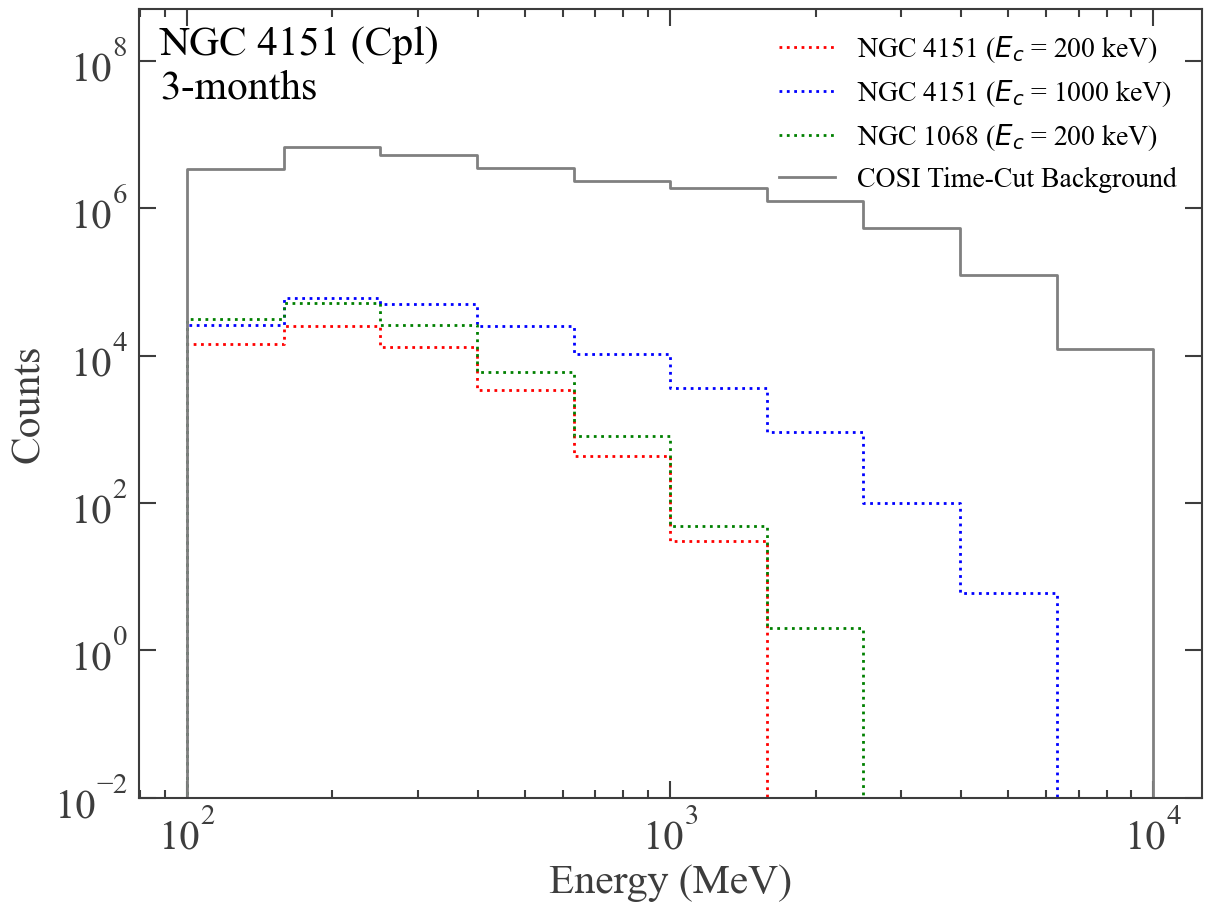

In [ ]:
NGC1068_ec200 = Histogram.open("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_200_DC4_COSI_cpl_60_fovCut.hdf5")
NGC1068_ec200 = Histogram.open("/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC1068_ec_200_DC4_COSI_cpl_60_fovCut.hdf5")
bkg = Histogram.open(background_file)

FONT_SIZE=30
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams.update({
    'font.weight': '550',
    'axes.titleweight': '550',
    'axes.labelweight': '550'
})

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)

ax.xaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', top='on', pad=8, labelsize=FONT_SIZE)
ax.xaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=12, width=1.5, direction='in', right='on', pad=8, labelsize=FONT_SIZE)
ax.yaxis.set_tick_params(which='minor', size=6, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

NGC1068_ec200.project("Em").draw(ax, label="NGC 1068 ($E_c$ = 200 keV)", color="red", linestyle="dotted")
NGC1068_ec1000.project("Em").draw(ax, label="NGC 1068 ($E_c$ = 1000 keV)", color="blue", linestyle="dotted")
NGC1068_ec200.project("Em").draw(ax, label="NGC 1068 ($E_c$ = 200 keV)", color="green", linestyle="dotted")
bkg.project("Em").draw(ax, label="COSI Time-Cut Background", color="grey")

text = f'NGC 1068 (Cpl) \n3-months'
ax.text(
    0.02, 0.98,
    text,
    transform=ax.transAxes,
    ha='left', va='top',
    fontsize=FONT_SIZE,
    fontweight='550'
)

# ax.set_xlim(180, 5500)
ax.set_yscale("log")
ax.set_xscale("log")

ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.set_ylim(1e-2, 5e8)

ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.legend(fontsize=20, loc='upper right', frameon=False)